# Scan

In this notebook, we scan the 2025 tiles for our 16 focus counties using the trained model.


## Setup

In [103]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import glob
import torch
import numpy as np
import rasterio
from rasterio import features
from shapely.geometry import shape, mapping, Polygon, MultiPolygon
from shapely.affinity import affine_transform
from shapely.geometry import GeometryCollection
import geopandas as gpd
from tqdm import tqdm
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


## Model

In [2]:
# Load the best model
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from model.model_utils import get_resnet34_unet_12bands

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model to get the model architecture 
model = get_resnet34_unet_12bands()

# Load trained weights
model.load_state_dict(torch.load("../model/best_model.pth", map_location=device))

# set to eval mode and move to device 
model.eval()
model.to(device)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(12, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

## Load and process tile

In [3]:
meta = pd.read_csv("../satellite_image/tiles_metadata.csv")

In [4]:
meta.head()

,tile_path,mask_path,county,label
0,D:\solar-data-china\tiles\Augmented_with_indic...,D:\solar-data-china\tiles\Augmented_mask\s2_Ha...,Augmented,1
1,D:\solar-data-china\tiles\Augmented_with_indic...,D:\solar-data-china\tiles\Augmented_mask\s2_Ha...,Augmented,1
2,D:\solar-data-china\tiles\Augmented_with_indic...,D:\solar-data-china\tiles\Augmented_mask\s2_Ha...,Augmented,0
3,D:\solar-data-china\tiles\Augmented_with_indic...,D:\solar-data-china\tiles\Augmented_mask\s2_Ha...,Augmented,1
4,D:\solar-data-china\tiles\Augmented_with_indic...,D:\solar-data-china\tiles\Augmented_mask\s2_Ha...,Augmented,1


In [5]:
# Filter rows where 'county' is not 'augmented'
filtered_meta = meta[meta['county'] != 'Augmented']

# Get the list of tif file paths
tif_files = filtered_meta['tile_path'].tolist()

In [60]:
def preprocess_tile(img, target_size=256):
    """
    - Resizes TIFF image to 256×256
    - Channels-first
    """
    # img shape: (H, W, C)
    # Resize each channel separately to avoid cv2.resize flattening channels
    if img.shape[2] > 1:
        img_resized = np.stack([
            cv2.resize(img[..., c], (target_size, target_size), interpolation=cv2.INTER_LINEAR)
            for c in range(img.shape[2])
        ], axis=-1)
    else:
        img_resized = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        img_resized = img_resized[..., np.newaxis]
    img_resized = np.transpose(img_resized, (2, 0, 1))  # HWC → CHW
    return img_resized

## Interference

In [61]:
THRESHOLD = 0.5  # probability threshold for binary mask

In [62]:
def infer_on_tile(tile):
    """
    Run inference on a single tile and return a binary mask.
    """
    with torch.no_grad():
        x = torch.tensor(tile).unsqueeze(0).float().to(device)  # [1,C,H,W]
        y = model(x)
        y_sigmoid = torch.sigmoid(y).cpu().numpy()[0, 0]  # [H,W]
        mask = (y_sigmoid < THRESHOLD).astype(np.uint8)
    return mask

In [64]:
def mask_to_geopolygons(mask: np.ndarray, transform, hole_area_threshold: float = 0):
    """
    Convert a binary mask (1 = object, 0 = background) into georeferenced polygons,
    optionally keeping only holes bigger than a threshold.

    Parameters
    ----------
    mask : np.ndarray
        2D array with 1 for objects and 0 for background.
    transform : affine.Affine
        The affine transform of the raster.
    hole_area_threshold : float
        Minimum area to keep a hole (in CRS units²). Holes smaller than this are removed.

    Returns
    -------
    gdf : geopandas.GeoDataFrame
        GeoDataFrame with one row per polygon.
    """
    polygons = []

    # Extract features
    for geom, val in features.shapes(mask.astype(np.uint8), mask=(mask == 1), transform=transform):
        if val != 1:
            continue

        shp = shape(geom)

        def process_poly(poly: Polygon) -> Polygon:
            if not isinstance(poly, Polygon):
                return None
            # Keep only holes (interiors) bigger than hole_area_threshold
            interiors = [
                ring for ring in poly.interiors
                if Polygon(ring).area > hole_area_threshold
            ]
            return Polygon(poly.exterior, interiors)

        # Handle Polygon or MultiPolygon
        if isinstance(shp, Polygon):
            cleaned = process_poly(shp)
            if cleaned and cleaned.is_valid and not cleaned.is_empty:
                polygons.append(cleaned)

        elif isinstance(shp, MultiPolygon):
            for subpoly in shp.geoms:
                cleaned = process_poly(subpoly)
                if cleaned and cleaned.is_valid and not cleaned.is_empty:
                    polygons.append(cleaned)

        # Ignore other types (GeometryCollection, LineString, etc.)

    gdf = gpd.GeoDataFrame(geometry=polygons)
    return gdf


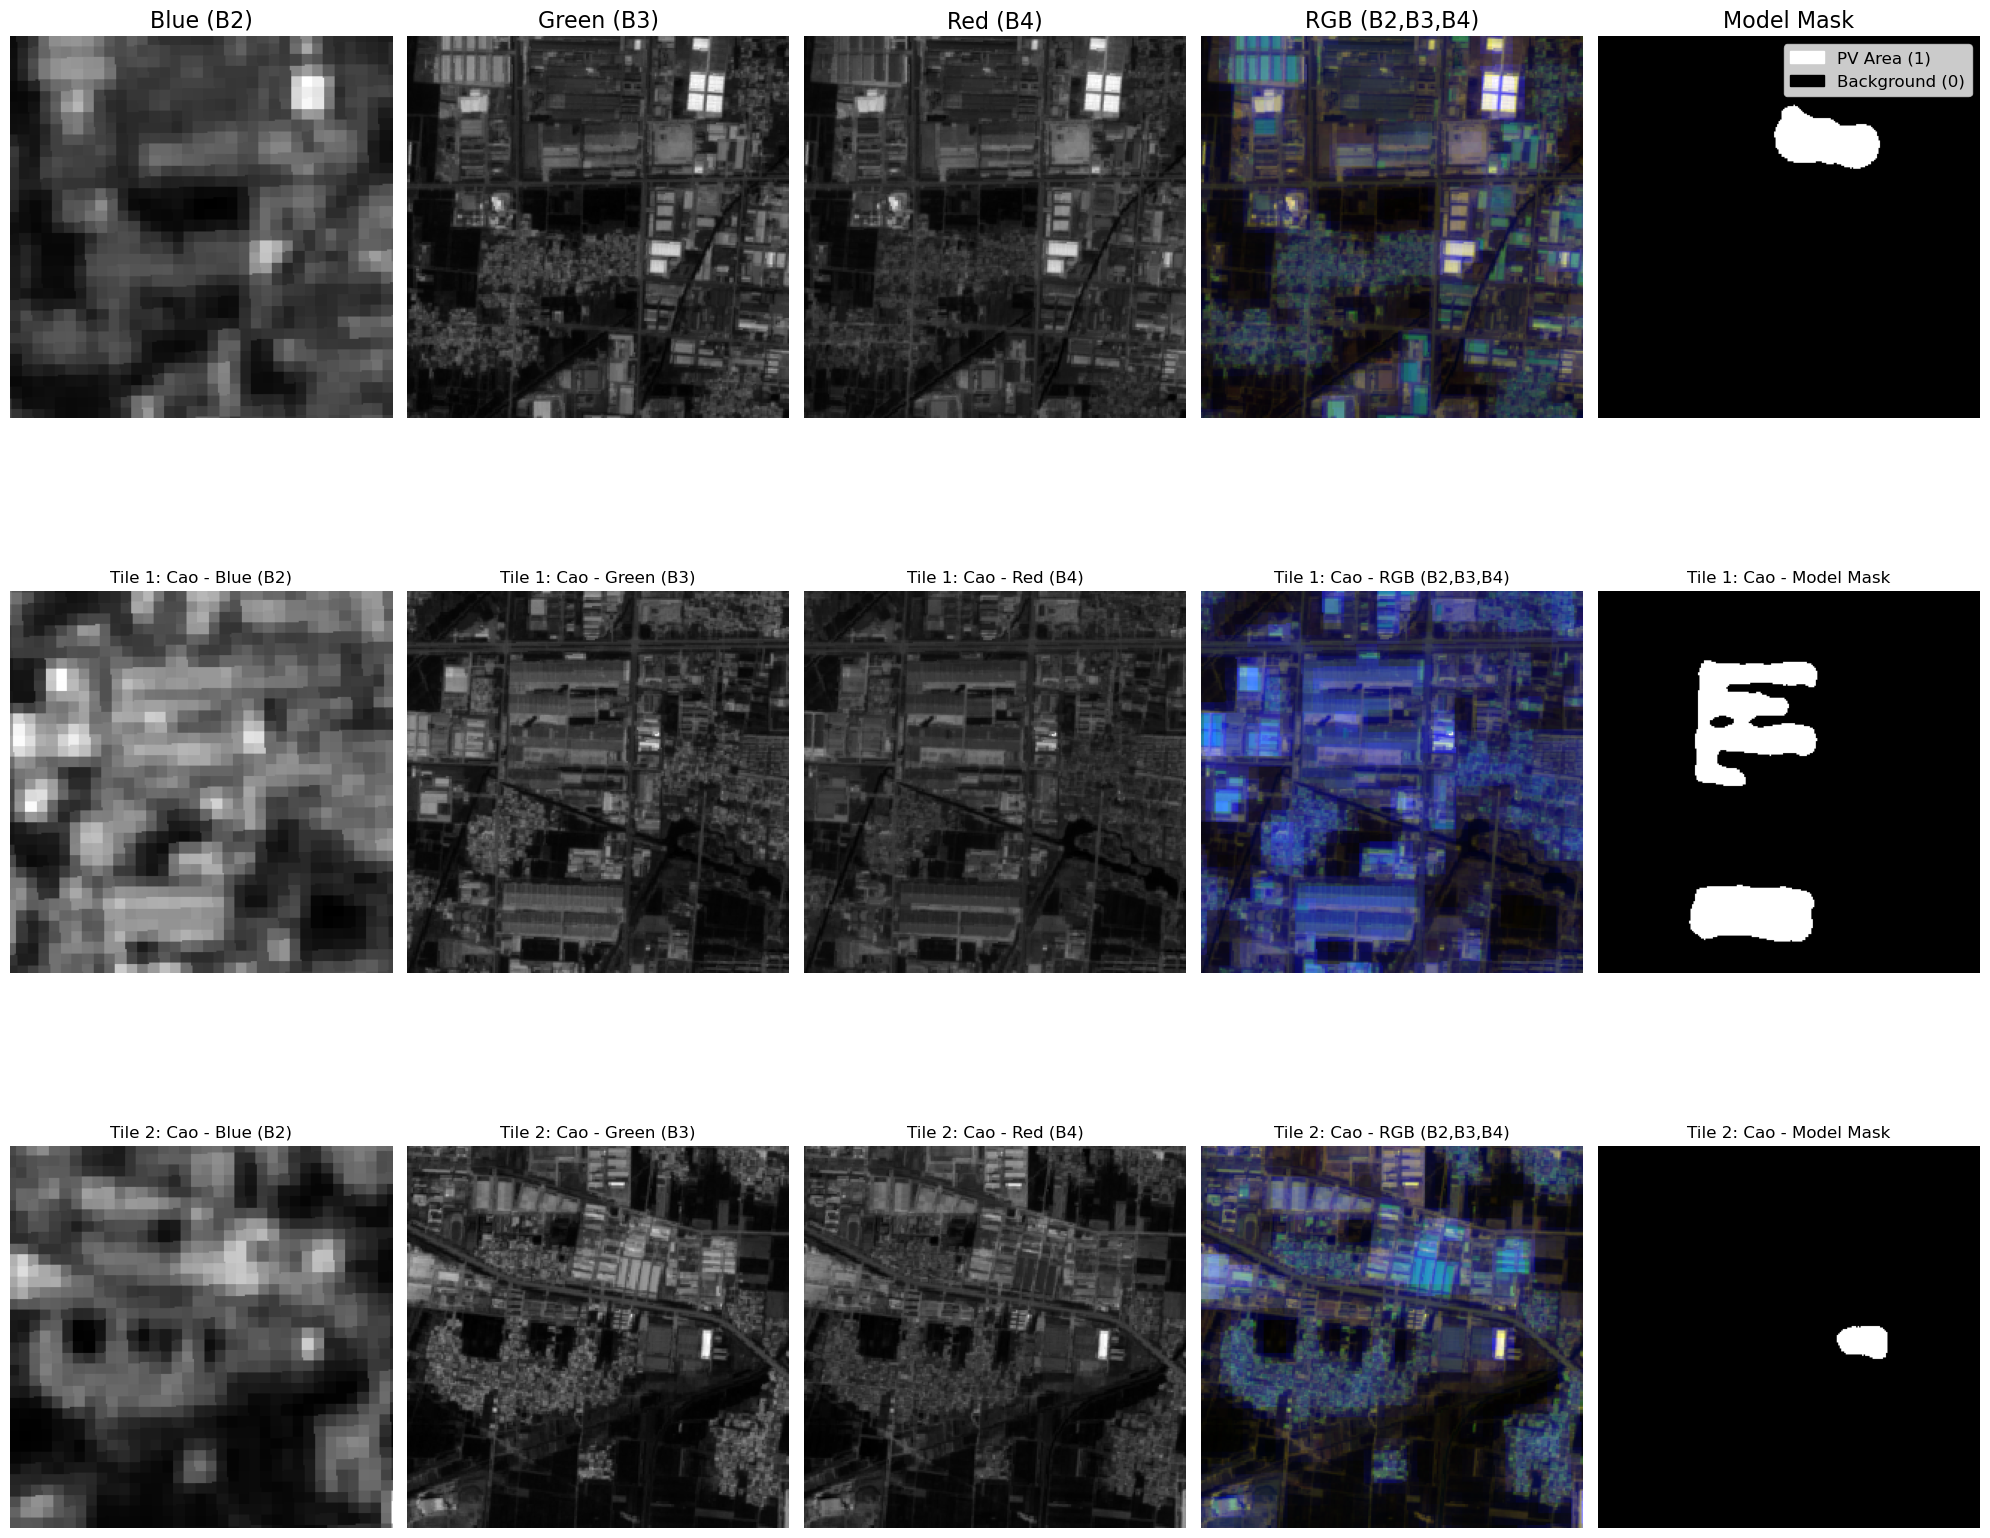

In [105]:
# Visual example of the model on 3 tiles 

df = meta[(meta['label'] == 1) & (meta['county'] != "Augmented")]

# Only use the 10m resolution bands: Sentinel-2 bands B2 (Blue), B3 (Green), B4 (Red)
# Band order in Sentinel-2 L2A 10m: [B2, B3, B4] = [Blue, Green, Red]
# We'll plot: Blue, Green, Red, RGB, Model Mask
num_examples = 3
num_examples = min(num_examples, len(df))

num_cols = 5
col_titles = ['Blue (B2)', 'Green (B3)', 'Red (B4)', 'RGB (B2,B3,B4)', 'Model Mask']

fig, axs = plt.subplots(num_examples, num_cols, figsize=(20, 6 * num_examples))

for i in range(num_examples):
    row = df.iloc[i]
    # Read the image tile (all bands)
    with rasterio.open(row['tile_path']) as src:
        tile_img = src.read()  # shape: (bands, H, W)
        # Check if tile has enough bands for the model
        if tile_img.shape[0] < 12:
            raise ValueError(
                f"Tile at {row['tile_path']} does not have at least 12 bands required for model inference. "
                f"Found {tile_img.shape[0]} bands."
            )
        # Only keep the 10m bands: B2 (Blue), B3 (Green), B4 (Red)
        # Assume band order is [B2, B3, B4] (0,1,2)
        blue = tile_img[0]
        green = tile_img[1]
        red = tile_img[2]

        # Prepare tile for model inference
        # Model expects all 12 channels (bands) as input, so use the full tile_img
        # tile_img shape: (12, H, W)
        tile_chw = preprocess_tile(tile_img.transpose(1, 2, 0))  # (C, H, W), preprocess_tile expects HWC

        # Calculate the mask with the model
        model_mask = infer_on_tile(tile_chw)

    # Plot Blue (B2)
    ax = axs[i, 0] if num_examples > 1 else axs[0]
    b_min, b_max = np.nanmin(blue), np.nanmax(blue)
    blue_disp = (blue - b_min) / (b_max - b_min + 1e-8)
    blue_disp = np.clip(blue_disp, 0, 1)
    ax.imshow(blue_disp, cmap='gray')
    ax.set_title(f"Tile {i}: {row['county']} - {col_titles[0]}")
    ax.axis('off')

    # Plot Green (B3)
    ax = axs[i, 1] if num_examples > 1 else axs[1]
    g_min, g_max = np.nanmin(green), np.nanmax(green)
    green_disp = (green - g_min) / (g_max - g_min + 1e-8)
    green_disp = np.clip(green_disp, 0, 1)
    ax.imshow(green_disp, cmap='gray')
    ax.set_title(f"Tile {i}: {row['county']} - {col_titles[1]}")
    ax.axis('off')

    # Plot Red (B4)
    ax = axs[i, 2] if num_examples > 1 else axs[2]
    r_min, r_max = np.nanmin(red), np.nanmax(red)
    red_disp = (red - r_min) / (r_max - r_min + 1e-8)
    red_disp = np.clip(red_disp, 0, 1)
    ax.imshow(red_disp, cmap='gray')
    ax.set_title(f"Tile {i}: {row['county']} - {col_titles[2]}")
    ax.axis('off')

    # Plot RGB composite (B2, B3, B4)
    ax_rgb = axs[i, 3] if num_examples > 1 else axs[3]
    rgb = np.stack([red_disp, green_disp, blue_disp], axis=-1)  # RGB order for display
    ax_rgb.imshow(rgb)
    ax_rgb.set_title(f"Tile {i}: {row['county']} - {col_titles[3]}")
    ax_rgb.axis('off')

    # Plot model mask
    ax_mask = axs[i, 4] if num_examples > 1 else axs[4]
    im = ax_mask.imshow(model_mask, cmap='gray',vmin=0, vmax=1 )
    ax_mask.set_title(f"Tile {i}: {row['county']} - {col_titles[4]}")
    ax_mask.axis('off')

    # Add legend to the model mask subplot
    # 0: background (black), 1: PV area (white)
    mask_1 = mpatches.Patch(color='white', label='PV Area (1)')
    mask_0 = mpatches.Patch(color='black', label='Background (0)')
    # Place legend only on the first row's mask subplot
    if i == 0:
        ax_mask.legend(handles=[mask_1, mask_0], loc='upper right', fontsize=12, frameon=True)

# Set column titles
for c in range(num_cols):
    if num_examples > 1:
        axs[0, c].set_title(col_titles[c], fontsize=16)
    else:
        axs[c].set_title(col_titles[c], fontsize=16)

plt.tight_layout()
plt.show()


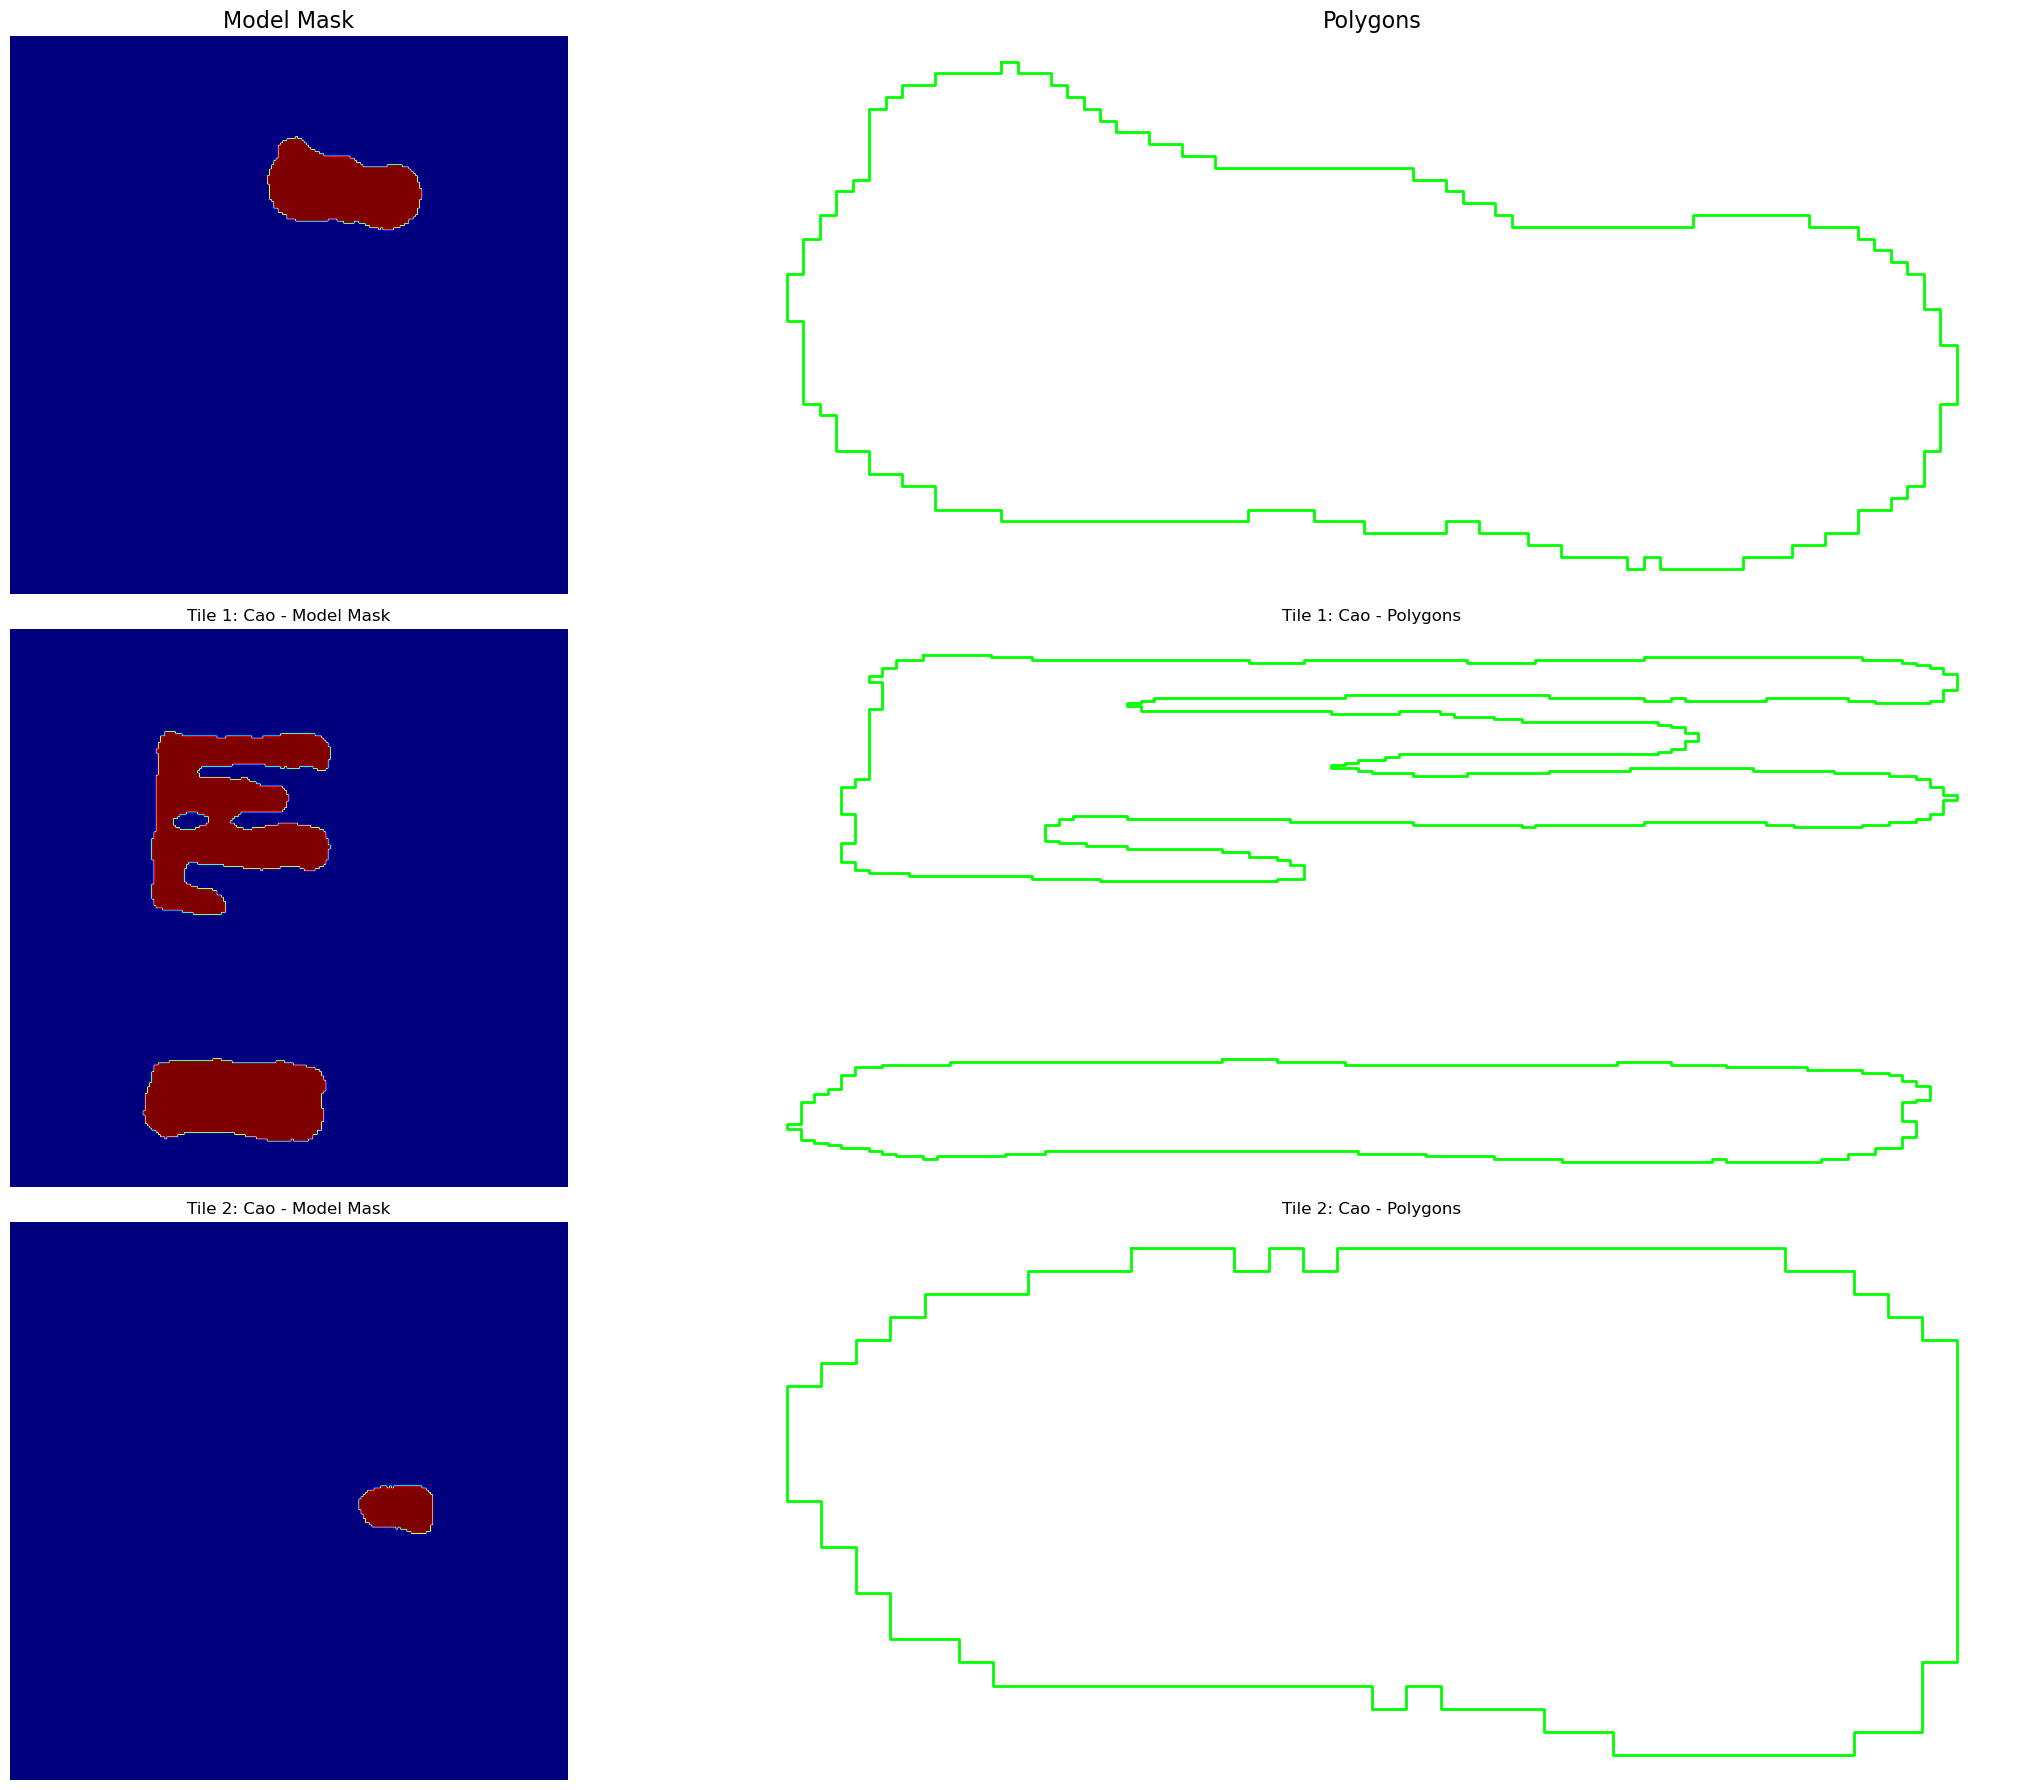

In [66]:
# Corrected code for displaying model mask and polygons

cdf = meta[(meta['label'] == 1) & (meta['county'] != "Augmented")]

num_examples = min(3, len(df))
num_cols = 2
col_titles = ['Model Mask', 'Polygons']

fig, axs = plt.subplots(num_examples, num_cols, figsize=(24, 6 * num_examples))

for i in range(num_examples):
    row = df.iloc[i]
    with rasterio.open(row['tile_path']) as src:
        tile_img = src.read()  # shape: (bands, H, W)

        if tile_img.shape[0] < 12:
            raise ValueError(
                f"Tile at {row['tile_path']} has only {tile_img.shape[0]} bands, "
                "but at least 12 are required."
            )

        # Extract 10m bands: B2 (Blue), B3 (Green), B4 (Red)
        blue = tile_img[0]
        green = tile_img[1]
        red = tile_img[2]

        # Prepare tile for model inference (expects shape C,H,W)
        tile_chw = preprocess_tile(tile_img.transpose(1, 2, 0))  # HWC to CHW

        # Predict mask
        model_mask = infer_on_tile(tile_chw)

        # Extract polygons from mask
        transform = src.transform
        hole_threshold = 0  # adjust as needed
        polygons = mask_to_geopolygons(model_mask, transform, hole_threshold)

    # Helper function to normalize bands for display
    def normalize_band(band):
        b_min, b_max = np.nanmin(band), np.nanmax(band)
        return np.clip((band - b_min) / (b_max - b_min + 1e-8), 0, 1)


    # Choose correct axis in axs (handles 1 or multiple examples)
    def get_ax(r, c):
        if num_examples > 1:
            return axs[r, c]
        else:
            return axs[c]

    # Plot Model Mask
    ax_mask = get_ax(i, 0)
    ax_mask.imshow(model_mask, cmap='jet')
    ax_mask.set_title(f"Tile {i}: {row['county']} - {col_titles[0]}")
    ax_mask.axis('off')

    # Plot Polygons on black background
    ax_poly = get_ax(i, 1)
    ax_poly.set_facecolor('black')
    for poly in polygons.geometry:
        if not poly.is_empty and hasattr(poly, "exterior"):
            x, y = poly.exterior.xy
            ax_poly.plot(x, y, color='lime', linewidth=2)
    ax_poly.set_title(f"Tile {i}: {row['county']} - {col_titles[1]}")
    ax_poly.axis('off')

# Set column titles once on top row or single row
for c in range(num_cols):
    ax = axs[0, c] if num_examples > 1 else axs[c]
    ax.set_title(col_titles[c], fontsize=16)

plt.tight_layout()
plt.show()


In [67]:
hole_threshold = 0 #fill the small holes

In [70]:
# Collect all detections
gdf_all = gpd.GeoDataFrame(columns=["geometry"])

for tif_path in tqdm(tif_files, desc="Processing TIFFs"):
    with rasterio.open(tif_path) as src:
        tile_img = src.read()
        tile_chw = preprocess_tile(tile_img.transpose(1, 2, 0))  # (C, H, W), preprocess_tile expects HWC

        # inference 
        model_mask = infer_on_tile(tile_chw)

        # convert mask to polygons
        transform = src.transform
        polys = mask_to_geopolygons(model_mask, transform, hole_threshold)

        # polys may be a GeoSeries or a list of shapely geometries
        # Ensure we pass a 1D list/series of geometries to GeoDataFrame
        crs = src.crs
        if hasattr(polys, "geometry"):  # GeoDataFrame or GeoSeries
            geoms = polys.geometry if hasattr(polys, "geometry") else polys
        else:
            geoms = polys

        # flatten if it's a list of lists (MultiPolygon)
        flat_geoms = []
        for g in geoms:
            if isinstance(g, GeometryCollection):
                flat_geoms.extend([geom for geom in g.geoms])
            else:
                flat_geoms.append(g)

        # Remove empty geometries
        flat_geoms = [g for g in flat_geoms if not g.is_empty]

        if len(flat_geoms) > 0:
            gdf = gpd.GeoDataFrame(geometry=flat_geoms, crs=crs)
            gdf_all = pd.concat([gdf_all, gdf], ignore_index=True)


Processing TIFFs: 100%|██████████| 10315/10315 [7:14:16<00:00,  2.53s/it]      


In [71]:
# save to geojson
OUTPUT_GEOJSON = "solar_panel_2025.geojson"

gdf_all.to_file(OUTPUT_GEOJSON, driver="GeoJSON")
print(f"Saved detections to {OUTPUT_GEOJSON}")

Saved detections to solar_panel_2025.geojson


In [56]:
gdf_all = gpd.read_file("solar_panel_2025.geojson")

In [76]:
# Calculate latitude and longitude of centroid for each polygon (assuming CRS is in meters, reproject to EPSG:4326)
gdf_centroids = gdf_all.copy()
gdf_centroids['centroid_geom'] = gdf_centroids['geometry'].centroid
gdf_centroids = gdf_centroids.set_geometry('centroid_geom').to_crs(epsg=4326)
gdf_all['lon'] = gdf_centroids.geometry.x
gdf_all['lat'] = gdf_centroids.geometry.y

# Calculate area (in the units of the CRS, e.g., square meters if projected)
gdf_all['area'] = gdf_all['geometry'].area

gdf_all

,geometry,lon,lat,area
0,"POLYGON ((1.22e+07 3.86e+06, 1.22e+07 3.86e+06...",109.870203,32.746048,1800.0
1,"POLYGON ((1.22e+07 3.86e+06, 1.22e+07 3.86e+06...",109.871390,32.744470,13400.0
2,"POLYGON ((1.22e+07 3.86e+06, 1.22e+07 3.86e+06...",109.869230,32.744255,11800.0
3,"POLYGON ((1.22e+07 3.86e+06, 1.22e+07 3.86e+06...",110.015944,32.730217,2300.0
4,"POLYGON ((1.28e+07 4.16e+06, 1.28e+07 4.16e+06...",115.390095,34.939270,153500.0
...,...,...,...,...
1466,"POLYGON ((1.19e+07 3.56e+06, 1.19e+07 3.56e+06...",106.520229,30.419517,25800.0
1467,"POLYGON ((1.19e+07 3.55e+06, 1.19e+07 3.55e+06...",106.471521,30.351798,3800.0
1468,"POLYGON ((1.18e+07 3.54e+06, 1.18e+07 3.54e+06...",106.441834,30.320344,2800.0
1469,"POLYGON ((1.19e+07 3.55e+06, 1.19e+07 3.55e+06...",106.572652,30.333974,76500.0


In [102]:
print(gdf_all.sort_values('area', ascending=True).head(50))

                                                                                                       geometry         lon        lat   area  \
104   POLYGON ((1.29e+07 3.82e+06, 1.29e+07 3.82e+06, 1.29e+07 3.82e+06, 1.29e+07 3.82e+06, 1.29e+07 3.82e+06))  115.771864  32.446125  100.0   
862   POLYGON ((1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06))  115.196044  40.517934  100.0   
861   POLYGON ((1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06, 1.28e+07 4.94e+06))  115.195775  40.518002  100.0   
1346  POLYGON ((1.15e+07 3.21e+06, 1.15e+07 3.21e+06, 1.15e+07 3.21e+06, 1.15e+07 3.21e+06, 1.15e+07 3.21e+06))  103.435660  27.658410  100.0   
1087  POLYGON ((1.28e+07 4.91e+06, 1.28e+07 4.91e+06, 1.28e+07 4.91e+06, 1.28e+07 4.91e+06, 1.28e+07 4.91e+06))  114.848307  40.316724  100.0   
1294  POLYGON ((1.15e+07 3.24e+06, 1.15e+07 3.24e+06, 1.15e+07 3.24e+06, 1.15e+07 3.24e+06, 1.15e+07 3.24e+06))  103.677307  27.91

In [96]:
# Get the longitude and latitude of the first row
first_row = gdf_all.iloc[861]
lat = first_row['lat']
lon = first_row['lon']

# Construct the Google Maps URL
google_maps_url = f"https://www.google.com/maps?q={lat},{lon}"
print(google_maps_url)



https://www.google.com/maps?q=40.51800248515502,115.19577486941627
